In [ ]:
import pandas as pd
import glob
import re
import os
import seaborn as sns
import numpy as np

In [ ]:
input_dir = '../../../data/GBM_LEAP_annotations/cell2location/cell_type_loadings/'
output_dir = '../../../data/Fig2/'

# Load TM annotation df
factor_map = pd.read_csv('../../../metadata/2.TM/factor_id_map.tsv', sep = '\t')\
    [['factor', 'environment']]
factor_map['environment'] = np.where(factor_map['environment']=='Immune (TAMs)',
                     'Immune (infiltrating)', factor_map['environment'])

# Load NMF cell type loadings from cell2loc
files = glob.glob(input_dir+'*')

ct_loadings_merged = []
for file in files:
    ct_loadings_merged.append(pd.read_csv(file, index_col = 0))
ct_loadings_merged = pd.concat(ct_loadings_merged, axis = 1).fillna(0)

# Summary plot

In [ ]:
# Order rows and cols for plotting:

cell_state_order = [
    "Hypoxic 1 (cell state)",
    "Stress-response TAMs",
    "Angiogenic TAMs",
    "Gliosis-like",
    "AC-gliosis-like 1",
    "Hypoxic 2 (cell state)",
    "Proliferative TAMs",
    "Monocytes",
    "RTN1+ TAMs",
    "Resident-TAMs",
    "Astrocyte-like TAMs",
    "Dendritic cells",
    "Proliferative AC-OPC-like",
    "NPC-neuronal-like 3",
    "Proliferative NPC-OPC-like",
    "Pericytes 1",
    "VLMC",
    "Endothelial (arteriole)",
    "Endothelial (capillary)",
    "OPC-neuronal-like",
    "NPC-neuronal-like 2",
    "NPC-neuronal-like 1",
    "AC progenitor-like 2",
    "AC progenitor-like 1",
    "AC-gliosis-like 4",
    "OPC-like 2",
    "OPC-like 1",
    "OPC-NPC-like 1",
    "Oligodendrocytes 2",
    "Oligodendrocytes 1",
    "Exc L2-3 IT",
    "Exc L4-5 IT",
    "Inh SST",
    "Inh PVALB",
    "Deep layer astrocytes",
    "Neural-support astrocytes",
    "Inflammatory astrocytes 1",
]

TM_order = [
    "Hypoxic 1",
    "Gliosis",
    "Gliosis transition",
    "Hypoxic 2",
    "Immune (infiltrating)",
    "Immune (resident)",
    "Proliferative",
    "Vasculature",
    "Dev-like (Neuron)",
    "Dev-like (AC)",
    "Gliosis (diffuse)",
    "Dev-like (OPC)",
    "White matter",
    "Grey matter",
    "Astrocyte rich",
    "Pial layer",
]

factor_map["environment"] = pd.Categorical(
    factor_map["environment"],
    categories=TM_order,
    ordered=True
)

factor_map = factor_map.sort_values("environment")

In [ ]:
ct_loadings_merged = ct_loadings_merged[factor_map['factor']]
ct_loadings_merged = ct_loadings_merged.reindex([i for i in cell_state_order if i in ct_loadings_merged.index])

<Axes: >

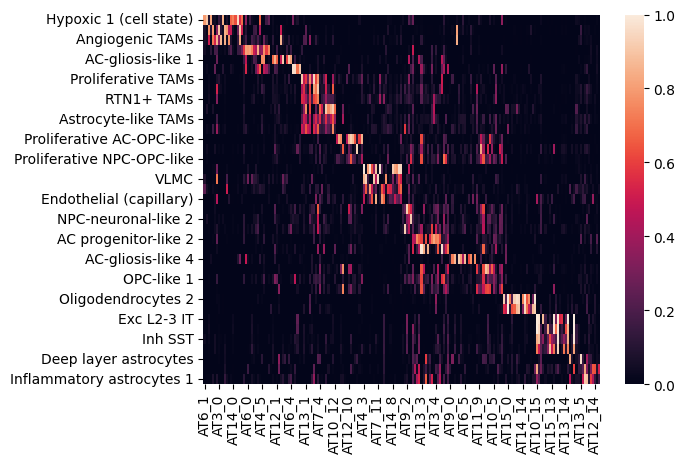

In [ ]:
sns.heatmap(ct_loadings_merged)

In [ ]:
ct_loadings_merged.to_csv(os.path.join(output_dir, 'Fig2b_loadings_plot.csv'))